In [1]:
import os
import sys
from glob import glob
import warnings

sys.path.insert(1, os.path.abspath(".."))
from pairs_python.core import pairs_quadtree as pqt

import time
import numpy
import pandas
from datetime import datetime, timedelta
import pytz
import geopandas
import shapely
from shapely import wkb
import pyproj
import contextily
#import sqlite3
#import pysqlite3 as sqlite3

import spatialite
"""
# sudo apt-get install libsqlite3-mod-spatialite
# pip install spatialite
import spatialite
with spatialite.connect('sl_temp.db') as db:
    print(db.execute('SELECT spatialite_version()').fetchone()[0])
"""

from functools import partial
import json

import vectorstore
"""
from importlib import reload 
reload(vectorstore)
"""

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import StrMethodFormatter, NullFormatter

In [2]:
original_dataset = 'kaggle_wildfire'  #'ne_10m_admin_0_countries' 'ne_10m_admin_1_states_provinces' 'ne_10m_admin_2_counties' 
table = 'Fires' #original_dataset #'ne_10m_admin_0_countries'
dataset = 'kaggle_wildfire'
dt_col = 'timestamp'
geom_col = 'geometry'  # Needs to be called 'geometry'
temporal_keys = [] #['year']
temporal_partitions = [] #['year']
overview_level = 8 #1 #8 #6
spatial_partition_levels = [4, 6] #[] 
filter_key_levels = [10, 14, 18, 22]

In [3]:
%%time
# See what tables are present in the sqlite database
def get_sqlite_tables(sqlite_path):
    con = spatialite.connect(sqlite_path)
    cur = con.cursor()
    cur.execute("SELECT name FROM sqlite_master WHERE type='table'")
    tables = cur.fetchall()
    cur.close()
    con.close()
    return tables

sqlite_path = '/data/vector/kaggle_wildfire/FPA_FOD_20170508.sqlite'
tables = get_sqlite_tables(sqlite_path)
#tables

CPU times: user 0 ns, sys: 7.83 ms, total: 7.83 ms
Wall time: 7.46 ms


In [4]:
%%time
# Load a table
def load_sqlite_table(sqlite_path, table, where_clause=None, limit=None):
    con = spatialite.connect(sqlite_path)    
    #con = sqlite3.connect(sqlite_path)
    con.enable_load_extension(True)
    con.load_extension("mod_spatialite")
    cur = con.cursor()
    # Load the data into a DataFrame
    query = f"SELECT * FROM {table}"
    if where_clause is not None:
        query = query + " " + where_clause
    if limit is not None:
        query = query + " " + f"LIMIT {limit}"
    print(query)
    df_sql = pandas.read_sql_query(query, con)
    cur.close()
    con.close()
    return df_sql

years = [2000, 2001]
where_clause = f"WHERE FIRE_YEAR IN ({str(years)[1:-1]})"
limit = 100 #None
df_sql = load_sqlite_table(sqlite_path, table, where_clause=where_clause, limit=limit)
print('df_sql', len(df_sql))
df_sql.tail(2)

SELECT * FROM Fires WHERE FIRE_YEAR IN (2000, 2001) LIMIT 100
df_sql 100
CPU times: user 47.9 ms, sys: 39.9 ms, total: 87.8 ms
Wall time: 87 ms


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape
98,120044,121245,FS-346287,FED,FS-FIRESTAT,FS,USORDEF,Deschutes National Forest,0601,Deschutes National Forest,...,A,43.966389,-121.305833,5.0,USFS,OR,None,None,None,b'\x00\x01\xad\x10\x00\x00\x1c\x98\xf5\xc5\x92...
99,120045,121246,FS-346288,FED,FS-FIRESTAT,FS,USORDEF,Deschutes National Forest,0601,Deschutes National Forest,...,B,43.958611,-121.256944,5.0,USFS,OR,None,None,None,b'\x00\x01\xad\x10\x00\x00\x18\xac\x17\xc7qP^\...


In [5]:
%%time
def dt_from_year_doy(row):
    return (datetime(row[0], 1, 1) + timedelta(int(row[1])-1)).replace(tzinfo=pytz.utc)

def create_timestamp_column(df, dt_col='timestamp'):
    df[dt_col] = df[['FIRE_YEAR', 'DISCOVERY_DOY']].apply(dt_from_year_doy, axis=1)
    df = df.sort_values(by=dt_col).reset_index(drop=True)
    return df

df_sql = create_timestamp_column(df_sql)
df_sql.tail(2)

CPU times: user 7.24 ms, sys: 0 ns, total: 7.24 ms
Wall time: 6.8 ms


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,LATITUDE,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape,timestamp
98,115044,116223,FS-341260,FED,FS-FIRESTAT,FS,USMOMTF,Mark Twain National Forest,0905,Mark Twain National Forest,...,37.651389,-91.281111,5.0,USFS,MO,None,None,None,b'\x00\x01\xad\x10\x00\x00\x80\xffs\xb9\xfd\xd...,2000-12-09 00:00:00+00:00
99,41841,42051,FS-1484830,FED,FS-FIRESTAT,FS,USMNSUF,Superior National Forest,0909,Superior National Forest,...,48.045000,-90.516667,5.0,USFS,MN,31,031,Cook,b'\x00\x01\xad\x10\x00\x00P\xa5\x14\x11\x11\xa...,2001-09-29 00:00:00+00:00


In [6]:
"""
%%time
# Convert binary geometry to shapely polygon
original_geom_col = 'GEOMETRY'
df_sql[geom_col] = df_sql[original_geom_col].apply(lambda x: wkb.loads(x))
if original_geom_col!=geom_col:
    del df_sql[original_geom_col]
df_sql.tail(2)
"""

"\n%%time\n# Convert binary geometry to shapely polygon\noriginal_geom_col = 'GEOMETRY'\ndf_sql[geom_col] = df_sql[original_geom_col].apply(lambda x: wkb.loads(x))\nif original_geom_col!=geom_col:\n    del df_sql[original_geom_col]\ndf_sql.tail(2)\n"

In [7]:
%%time
def make_geometry_table(df_sql):
    # FIRE_SIZE is in acres. 
    # So let's approximate the geometry by buffereing the point to the area of the FIRE_SIZE (ellipse in WGS84)
    gdf = geopandas.GeoDataFrame(df_sql, geometry=geopandas.points_from_xy(df_sql.LONGITUDE, df_sql.LATITUDE), crs="EPSG:4326")
    # Switch projection to Pseudo Merkator (almost conformal projection to preserve angles)
    gdf = gdf.to_crs("EPSG:3857")
    # Mercator scale factor (for areas use the square)
    scale_factor = numpy.cos(gdf['LATITUDE'] / 180. * numpy.pi)
    # Acres to meters
    gdf['radius'] = numpy.sqrt(gdf['FIRE_SIZE'] * 4046.8564224 / numpy.pi) / scale_factor
    # Buffer to create a circle
    gdf['geometry'] = gdf['geometry'].buffer(gdf['radius'])
    del gdf['radius']
    # Switch back to WGS84
    gdf = gdf.to_crs("EPSG:4326")
    return gdf

gdf_sql = make_geometry_table(df_sql)
gdf_sql.tail(2)

CPU times: user 33.8 ms, sys: 1.01 ms, total: 34.8 ms
Wall time: 34.1 ms


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape,timestamp,geometry
98,115044,116223,FS-341260,FED,FS-FIRESTAT,FS,USMOMTF,Mark Twain National Forest,0905,Mark Twain National Forest,...,-91.281111,5.0,USFS,MO,None,None,None,b'\x00\x01\xad\x10\x00\x00\x80\xffs\xb9\xfd\xd...,2000-12-09 00:00:00+00:00,"POLYGON ((-91.28011 37.65139, -91.28012 37.651..."
99,41841,42051,FS-1484830,FED,FS-FIRESTAT,FS,USMNSUF,Superior National Forest,0909,Superior National Forest,...,-90.516667,5.0,USFS,MN,31,031,Cook,b'\x00\x01\xad\x10\x00\x00P\xa5\x14\x11\x11\xa...,2001-09-29 00:00:00+00:00,"POLYGON ((-90.51618 48.04500, -90.51619 48.044..."


In [8]:
"""
%%time
# Create the Geolab vectorstore
id_col = 'OBJECTID'
intersection_policy = 'original' #'cut' # 'original'
vs = vectorstore.Vectorstore(
    dataset=dataset, temporal_keys=temporal_keys, temporal_partitions=temporal_partitions, 
    overview_level=overview_level, spatial_partition_levels=spatial_partition_levels, filter_key_levels=filter_key_levels,
    dt_col=dt_col, geom_col=geom_col, id_col=id_col, intersection_policy=intersection_policy,
)
vs.load_geodataframe(gdf_sql)
vs.gdf_intersection.tail(2)

# Write the vectorstore to parquet
vs.to_parquet()
"""

"\n%%time\n# Create the Geolab vectorstore\nid_col = 'OBJECTID'\nintersection_policy = 'original' #'cut' # 'original'\nvs = vectorstore.Vectorstore(\n    dataset=dataset, temporal_keys=temporal_keys, temporal_partitions=temporal_partitions, \n    overview_level=overview_level, spatial_partition_levels=spatial_partition_levels, filter_key_levels=filter_key_levels,\n    dt_col=dt_col, geom_col=geom_col, id_col=id_col, intersection_policy=intersection_policy,\n)\nvs.load_geodataframe(gdf_sql)\nvs.gdf_intersection.tail(2)\n\n# Write the vectorstore to parquet\nvs.to_parquet()\n"

# Upload by year

In [9]:
%%time
limit = None #100 #None

id_col = 'OBJECTID'
intersection_policy = 'original' #'original' #'cut' # 'both'

start_year = 1990
end_year = 2020
num = 10 # Number of years uploaded together
for years in [list(range(s, s+num)) for s in numpy.arange(start_year, end_year, num)]:
    loop_start = time.time()

    # Read the SQLite and filter by year
    where_clause = f"WHERE FIRE_YEAR IN ({str(years)[1:-1]})"
    df_sql = load_sqlite_table(sqlite_path, table, where_clause=where_clause, limit=limit)
    print('df_sql', len(df_sql))

    # Create timestamp column
    df_sql = create_timestamp_column(df_sql)

    # Convert to GeoDataFrame
    gdf_sql = make_geometry_table(df_sql)

    # Create or initialize an existing Geolab vectorstore
    vs = vectorstore.Vectorstore(
        dataset=dataset, temporal_keys=temporal_keys, temporal_partitions=temporal_partitions, 
        overview_level=overview_level, spatial_partition_levels=spatial_partition_levels, filter_key_levels=filter_key_levels,
        dt_col=dt_col, geom_col=geom_col, id_col=id_col, intersection_policy=intersection_policy,
    )

    # Upload data
    vs.load_geodataframe(gdf_sql)
    #vs.gdf_intersection.tail(2)

    # Write the vectorstore to parquet
    vs.to_parquet(append=True)
    print('Upload time for years', years, 'in seconds', round(time.time()-loop_start, 3))

SELECT * FROM Fires WHERE FIRE_YEAR IN (1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999)
df_sql 572148
Upload time for years [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999] in seconds 142.061
SELECT * FROM Fires WHERE FIRE_YEAR IN (2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009)
df_sql 858083
Upload time for years [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009] in seconds 282.145
SELECT * FROM Fires WHERE FIRE_YEAR IN (2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019)
df_sql 450234
Upload time for years [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019] in seconds 225.382
CPU times: user 10min 13s, sys: 49 s, total: 11min 2s
Wall time: 10min 49s


In [11]:
from importlib import reload 
reload(vectorstore)
vs = vectorstore.Vectorstore(dataset=dataset)

In [12]:
# Discover the vectorstore cells of the dataset
gdf_meta = vs.gdf_meta
gdf_meta.tail(2)

,spatial_key,overview_level,geometry,partition_level4,partition_level6,overview_key,filepath
336,9490,8,"POLYGON ((-68.85094 46.31488, -68.85094 48.412...",37,593,level8_9490,/data/vector/vectorstore/kaggle_wildfire/parti...
337,9491,8,"POLYGON ((-66.75379 46.31488, -66.75379 48.412...",37,593,level8_9491,/data/vector/vectorstore/kaggle_wildfire/parti...


In [13]:
%%time
# Calculate and write the overview statistics
numeric_layers = ['FIRE_SIZE', 'DISCOVERY_DOY']
timestamp_layers = ['timestamp']
categorical_layers = ['STATE', 'STAT_CAUSE_DESCR']
percentiles = [0, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]
vs.calc_overview_statistics(
    numeric_layers=numeric_layers,
    timestamp_layers=timestamp_layers,
    categorical_layers=categorical_layers,
    percentiles=percentiles,
)

CPU times: user 27.3 s, sys: 1.33 s, total: 28.6 s
Wall time: 26.2 s


In [14]:
%%time
# Calculate and write the pyramids
vs.calc_pyramids(verbose=False)

CPU times: user 1min 51s, sys: 8.63 s, total: 2min
Wall time: 1min 40s


In [25]:
from importlib import reload 
reload(vectorstore)

<module 'vectorstore' from '/data/mfreitag/software/vector/vectorstore.py'>

In [26]:
vs = vectorstore.Vectorstore(dataset=dataset)

In [27]:
vs.read_pyramid(5, 'STAT_CAUSE_DESCR', histogram=True)

,Arson,Campfire,Children,Debris Burning,Equipment Use,Fireworks,Lightning,Miscellaneous,Missing/Undefined,Powerline,Railroad,Smoking,Structure
pyramid_level5,,,,,,,,,,,,,
41,10,65,0,12,8,3,9,65,9715,0,1,7,0
47,22205,15020,8152,18279,45082,746,68206,59508,16340,1630,1361,7932,208
56,609,19,50,2422,210,2,48,2065,183,46,25,56,0
57,1887,505,1143,1860,2916,52,6612,2528,876,133,3364,234,13
58,13926,15238,8033,42775,22318,3414,91982,58044,23231,4458,2103,7602,909
59,180433,20423,22382,284135,51604,1830,37975,98479,67881,4124,20888,19609,1354
60,142,1,0,4,0,0,2,110,21821,0,0,1,0
62,34476,5056,11437,37794,10527,293,7583,65515,10707,1488,1855,11803,251
128,0,0,0,4,0,0,3,0,1,0,0,0,0


In [28]:
%%time
# Query the layer
#query_polygon = shapely.geometry.box(-106, 33, -105, 34)
query_polygon = shapely.geometry.box(-122.5, 40.25, -122.25, 40.50)
#query_polygon = shapely.geometry.box(-180, -90, 180, 90)
#query_polygon = shapely.geometry.box(-110, 40, -90, 50)
query_dt_start = datetime(1980, 1, 1).replace(tzinfo=pytz.utc)
query_dt_end = datetime(2023, 1, 1).replace(tzinfo=pytz.utc)
query_intersection_policy = 'cut' #'original'
geometry_area = True
geometry_length = False

"""
query_polygon = None
query_dt_start = None
query_dt_end = None
query_intersection_policy = 'original' #'original'
"""
vs.query_vectorstore(
    query_polygon=query_polygon, query_dt_start=query_dt_start, query_dt_end=query_dt_end, 
    query_intersection_policy=query_intersection_policy, geometry_area=geometry_area, geometry_length=geometry_length=, verbose=False
)
gdf_query = vs.gdf_query
gdf_query.tail(2)

SyntaxError: invalid syntax (<unknown>, line 20)

<AxesSubplot:>

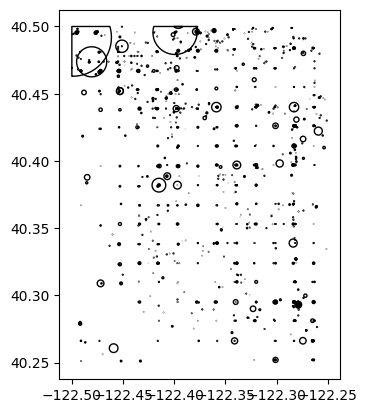

In [19]:
gdf_query.plot(color='None')

In [20]:
df_intersected = vs.read_intersected_geometry()
df_intersected.tail(3)

,OBJECTID,overview_key
2855,1876244,"[level8_3033, level8_3036]"
2856,1876300,"[level8_3045, level8_3056]"
2857,1878362,"[level8_3047, level8_3058]"


In [21]:
df1 = df_intersected[df_intersected[vs.overview_key_col].apply(lambda x: len(x))>2].reset_index(drop=True)
df1.tail(3)

,OBJECTID,overview_key
25,1795842,"[level8_8531, level8_8537, level8_8540]"
26,1803739,"[level8_8530, level8_8531, level8_8536, level8..."
27,1860032,"[level8_8532, level8_8533, level8_8535]"


<AxesSubplot:>

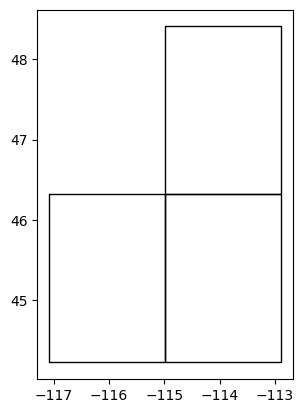

In [22]:
# One example of a multi-overview polygon
overview_keys = df1.iloc[-1][vs.overview_key_col]
gdf_meta_keys = gdf_meta[gdf_meta[vs.overview_key_col].isin(overview_keys)]
gdf_meta_keys.plot(color='none')

In [23]:
gdf = []
for filepath in gdf_meta_keys['filepath']:
    gdf.append(geopandas.read_parquet(filepath))
    
gdf = pandas.concat(gdf).reset_index(drop=True)
gdf.tail(3)

,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,spatial_key,overview_level,intersection_flag,overview_key,partition_level4,partition_level6,filter_key_level10,filter_key_level14,filter_key_level18,filter_key_level22
28447,1792563,300203856,FS-6365925,FED,FS-FIRESTAT,FS,USMTLNF,Lolo National Forest,0116,Lolo National Forest,...,8535,8,False,level8_8535,33,533,136563.0,34960188.0,8.949808e+09,NaN
28448,1829511,300249309,SFO-2015MTNWS000147,NONFED,ST-NASF,ST/C&L,USMTNWS,Northwestern Land Office,MTNWS,Northwestern Land Office,...,8535,8,False,level8_8535,33,533,136572.0,34962454.0,8.950388e+09,NaN
28449,1792564,300203857,FS-6700722,FED,FS-FIRESTAT,FS,USMTLNF,Lolo National Forest,0116,Lolo National Forest,...,8535,8,False,level8_8535,33,533,136564.0,34960554.0,8.949902e+09,NaN


<AxesSubplot:>

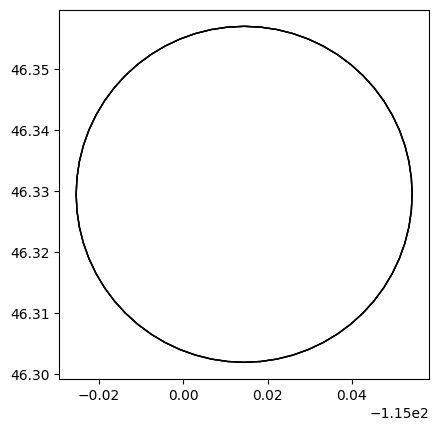

In [24]:
gdf[gdf[vs.id_col]==1635720].plot(color='none')